# Ames Housing: End-to-End Model Development

**Summary & Objective**
The goal of this project is to predict residential house prices in Ames, Iowa, using an advanced regression workflow. We progress from manual data exploration and cleaning to a robust, automated Scikit-learn Pipeline.

## 1. Environment & Data Loading

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [37]:
# Load data
train = pd.read_csv('../data/train.csv')
print(f"Dataset loaded with {train.shape[0]} rows and {train.shape[1]} columns.")

# Which columns are Numerical vs Categorical?
num_cols = train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = train.select_dtypes(include=['object']).columns

print(f"Numerical Columns: {len(num_cols)}")
print(f"Categorical Columns: {len(cat_cols)}")

Dataset loaded with 1460 rows and 81 columns.
Numerical Columns: 38
Categorical Columns: 43


## 2. Phase I: Manual Research & EDA Findings

**Target Variable AnalysisObservation**

The SalePrice distribution exhibits a high positive skew of 1.88.Inference: Linear models and gradient boosting often struggle with skewed targets. We will apply a Log Transformation to normalize the distribution for training.

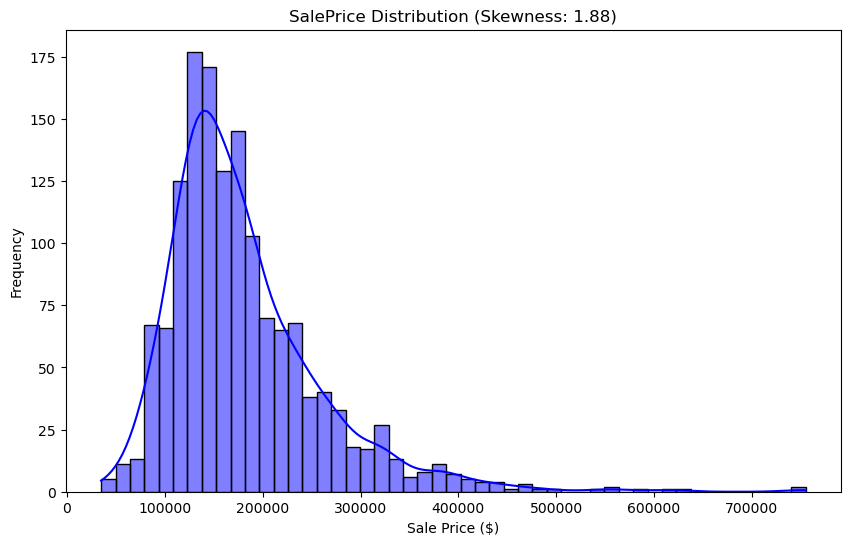

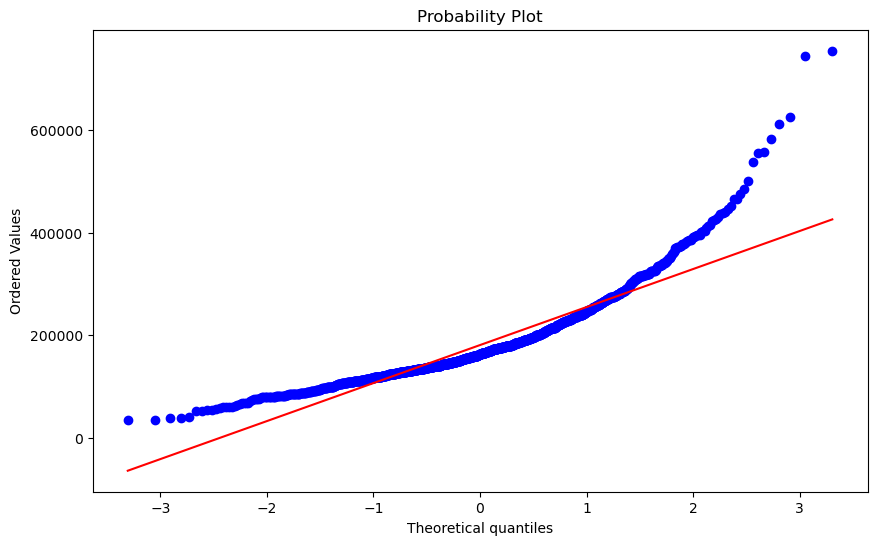

In [38]:
# 1. Distribution Plot
plt.figure(figsize=(10, 6))
sns.histplot(train['SalePrice'], kde=True, color='blue')
plt.title(f"SalePrice Distribution (Skewness: {train['SalePrice'].skew():.2f})")
plt.xlabel("Sale Price ($)")
plt.ylabel("Frequency")
plt.show()

# 2. Probability Plot (Q-Q Plot) to check for normality
from scipy import stats
plt.figure(figsize=(10, 6))
stats.probplot(train['SalePrice'], plot=plt)
plt.show()

### Missing Value Imputation

In [39]:
# Calculate percentage of missing data per column
missing_pct = (train.isnull().sum() / len(train)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
missing_pct

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtCond         2.534247
BsmtQual         2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

**Outlier DetectionObservation**

Scatter plots of GrLivArea vs. SalePrice reveal two specific properties with >4,000 sq ft but exceptionally low prices ($< \$300k$).Inference: These are statistical outliers that do not follow the general market trend. We will manually drop these to prevent the model from learning incorrect patterns.

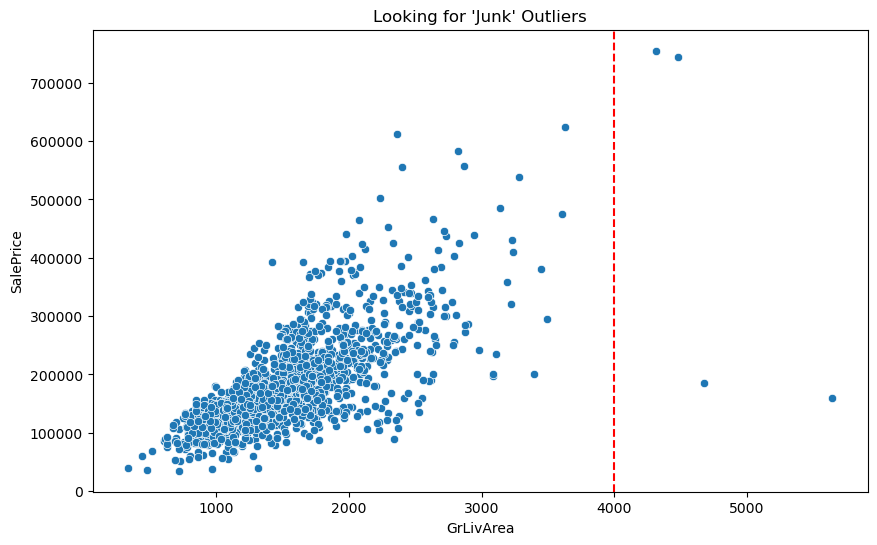

Number of dangerous outliers: 2


In [40]:
# Manual Check: GrLivArea vs SalePrice
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train)
plt.axvline(x=4000, color='r', linestyle='--') # Common threshold for this dataset
plt.title("Looking for 'Junk' Outliers")
plt.show()

# Filter check
outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)]
print(f"Number of dangerous outliers: {len(outliers)}")

### Check correlation

**Observation:**
1. The correlation heatmap reveals that OverallQual (0.79) and GrLivArea (0.71) have the strongest linear relationship with SalePrice.
2. TotalBsmtSF and 1stFlrSF show high correlation with each other (multicollinearity), but both are strong predictors of the target.

**Inference:**
1. We will prioritize these high-correlation numerical features for our pipeline. 
2. However, to handle the multicollinearity, tree-based models like XGBoost are ideal as they are less sensitive to correlated features than linear regression.

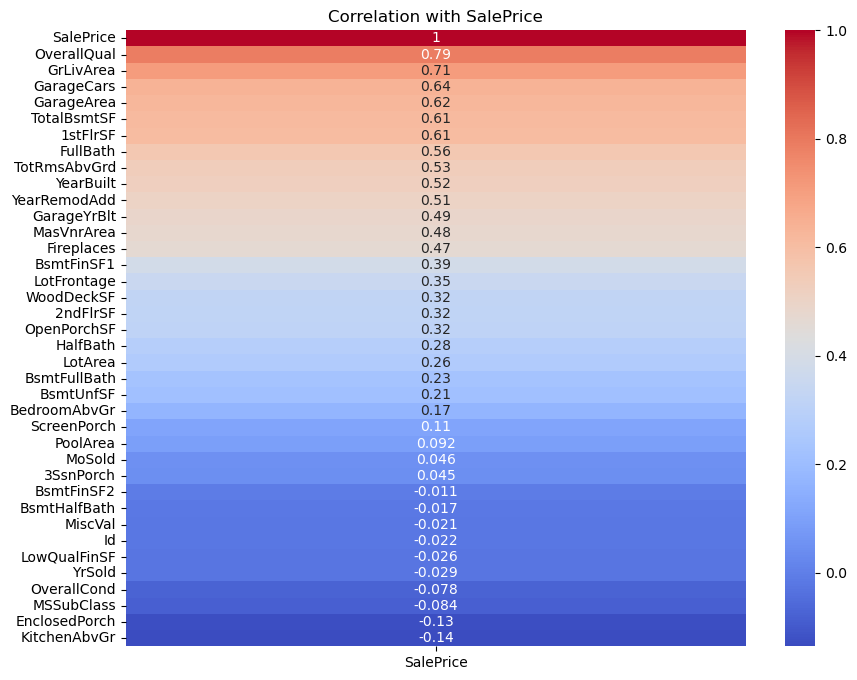

In [41]:
# Plot correlations with SalePrice
plt.figure(figsize=(10, 8))
correlation_matrix = train[num_cols].corr()
sns.heatmap(correlation_matrix[['SalePrice']].sort_values(by='SalePrice', ascending=False), 
            annot=True, cmap='coolwarm')
plt.title("Correlation with SalePrice")
plt.show()

### Apply Transformation

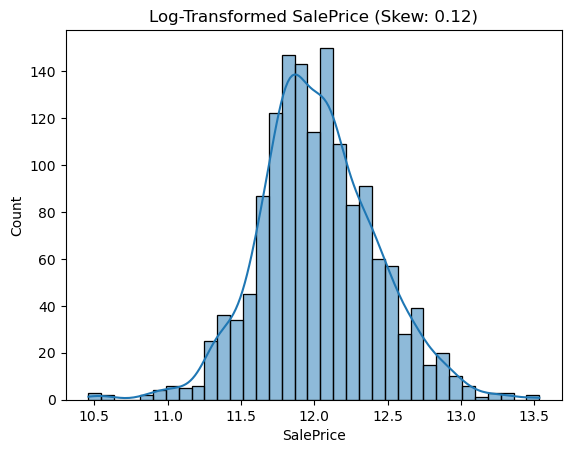

Post-EDA Dataset Shape: (1166, 10)


In [42]:
# Apply EDA-driven changes

# 1. DROP OUTLIERS (Identified in Phase I)
# Removing the two high-area/low-price outliers
train = train.drop(train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index)

# 2. FEATURE SELECTION (Driven by Correlation Plot)
# Selecting top correlated features + categorical variables for context
num_features = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'YearBuilt','LotFrontage']
cat_features = ['Neighborhood', 'ExterQual', 'KitchenQual']

# 3. TARGET TRANSFORMATION (Driven by Skewness Analysis)
y = np.log1p(train['SalePrice'])
X = train[num_features + cat_features]


# Visualize the improvement
sns.histplot(y, kde=True)
plt.title(f"Log-Transformed SalePrice (Skew: {y.skew():.2f})")
plt.show()


# 4. INITIAL SPLIT
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Post-EDA Dataset Shape: {X_train.shape}")

## 3. Phase II: Manual Prototype (The "Messy" Way)

In [44]:
# 4. TRAIN-TEST SPLIT
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. MANUAL PREPROCESSING (The "Detective" Phase)
# Calculating median on Training set to fill both (Prevents Data Leakage)
lot_frontage_median = X_train['LotFrontage'].median()
X_train['LotFrontage'] = X_train['LotFrontage'].fillna(lot_frontage_median)
X_val['LotFrontage'] = X_val['LotFrontage'].fillna(lot_frontage_median)

# Fill categorical NaNs and perform One-Hot Encoding
X_train = X_train.fillna('None')
X_val = X_val.fillna('None')

X_train_enc = pd.get_dummies(X_train)
X_val_enc = pd.get_dummies(X_val)

## 4. Training a simple model

In [45]:
# ALIGNMENT: Ensure validation columns match training exactly
X_val_enc = X_val_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# 6. MODEL DEVELOPMENT (XGBOOST)
xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42)
xgb.fit(X_train_enc, y_train)

# 7. INFERENCE & EVALUATION
log_preds = xgb.predict(X_val_enc)
final_preds = np.expm1(log_preds)
final_actuals = np.expm1(y_val)

print(f"Manual Research Workflow Complete.")
print(f"XGBoost MAE: ${mean_absolute_error(final_actuals, final_preds):,.2f}")

Manual Research Workflow Complete.
XGBoost MAE: $17,956.87
